# Automobile Segmentation with K-Means

## Objective
This notebook uses K-Means clustering to identify groups of automobiles with similar technical and physical characteristics. The resulting segments provide an unsupervised view of the data and can be evaluated as an optional input for later price-prediction models.

## Analytical question
Do the automobiles in the dataset form distinct segments based on their technical characteristics?


## Project structure

```text
automobile-price-analysis/
├── data/
│   └── processed/
│       ├── automobiles_clean.csv
│       └── automobiles_with_clusters.csv
└── notebooks/
    ├── 01_eda_preprocessing.ipynb
    └── 02_clustering.ipynb
```

This notebook uses the cleaned data exported by Notebook 01.


## Imports and configuration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown

from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='deep')


## Load cleaned data

The analysis begins with the cleaned dataset from Notebook 01. This preserves the earlier data-quality decisions and ensures that clustering and later modeling use the same source file.


In [2]:
file_path = Path('../data/processed/automobiles_clean.csv')

if not file_path.exists():
    raise FileNotFoundError(
        f'File not found: {file_path.resolve()}\n'
        'Run Notebook 01 first to create automobiles_clean.csv.'
    )

df_clean = pd.read_csv(file_path)

print(f'Loaded {df_clean.shape[0]} rows and {df_clean.shape[1]} columns.')
display(df_clean.head())


Loaded 201 rows and 26 columns.


,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


## Clustering features

The selected features describe engine capacity, power, vehicle size, weight, and fuel efficiency. Price is excluded from the clustering inputs so that the groups reflect vehicle characteristics rather than price tiers. Price is used later to interpret the completed segments.


In [3]:
cluster_features = [
    'engine_size',
    'horsepower',
    'curb_weight',
    'wheel_base',
    'city_mpg',
    'highway_mpg'
]

missing_features = [col for col in cluster_features if col not in df_clean.columns]
if missing_features:
    raise ValueError(f'Missing columns in the cleaned dataset: {missing_features}')

X_cluster = df_clean[cluster_features].copy()
display(X_cluster.describe().T)


,count,mean,std,min,25%,50%,75%,max
engine_size,201.0,126.875622,41.546834,61.0,98.0,120.0,141.0,326.0
horsepower,199.0,103.396985,37.553843,48.0,70.0,95.0,116.0,262.0
curb_weight,201.0,2555.666667,517.296727,1488.0,2169.0,2414.0,2926.0,4066.0
wheel_base,201.0,98.797015,6.066366,86.6,94.5,97.0,102.4,120.9
city_mpg,201.0,25.179104,6.423220,13.0,19.0,24.0,30.0,49.0
highway_mpg,201.0,30.686567,6.815150,16.0,25.0,30.0,34.0,54.0


## Imputation and scaling

K-Means uses distances between observations, so the input variables must be on comparable scales. Median imputation handles remaining missing feature values, and standardization prevents variables with larger numerical units, such as curb weight, from dominating the distance calculations.


In [4]:
cluster_imputer = SimpleImputer(strategy='median')
X_cluster_imputed = cluster_imputer.fit_transform(X_cluster)

cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster_imputed)

X_cluster_scaled_df = pd.DataFrame(
    X_cluster_scaled,
    columns=cluster_features,
    index=df_clean.index
)

display(X_cluster_scaled_df.describe().round(2))


,engine_size,horsepower,curb_weight,wheel_base,city_mpg,highway_mpg
count,201.00,201.00,201.00,201.00,201.00,201.00
mean,-0.00,0.00,0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.59,-1.48,-2.07,-2.02,-1.90,-2.16
25%,-0.70,-0.89,-0.75,-0.71,-0.96,-0.84
50%,-0.17,-0.22,-0.27,-0.30,-0.18,-0.10
75%,0.34,0.34,0.72,0.60,0.75,0.49
max,4.80,4.26,2.93,3.65,3.72,3.43


## Selecting the number of clusters

K-Means requires the number of clusters, k, to be selected in advance. The elbow curve shows how compact the clusters become as k increases, while the silhouette score measures how well-separated and internally cohesive the groups are. The final choice balances these diagnostics with interpretability.


In [5]:
inertias = []
silhouette_scores = []
k_values = list(range(2, 9))

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, labels))

k_results = pd.DataFrame({
    'k': k_values,
    'inertia': inertias,
    'silhouette_score': silhouette_scores
})

display(k_results.round(3))


c:\Users\hp\miniconda3\envs\da\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hp\miniconda3\envs\da\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hp\miniconda3\envs\da\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hp\miniconda3\envs\da\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have

,k,inertia,silhouette_score
0,2,592.042,0.453
1,3,436.629,0.368
2,4,335.097,0.382
3,5,262.211,0.410
4,6,225.090,0.383
5,7,204.406,0.367
6,8,185.033,0.334


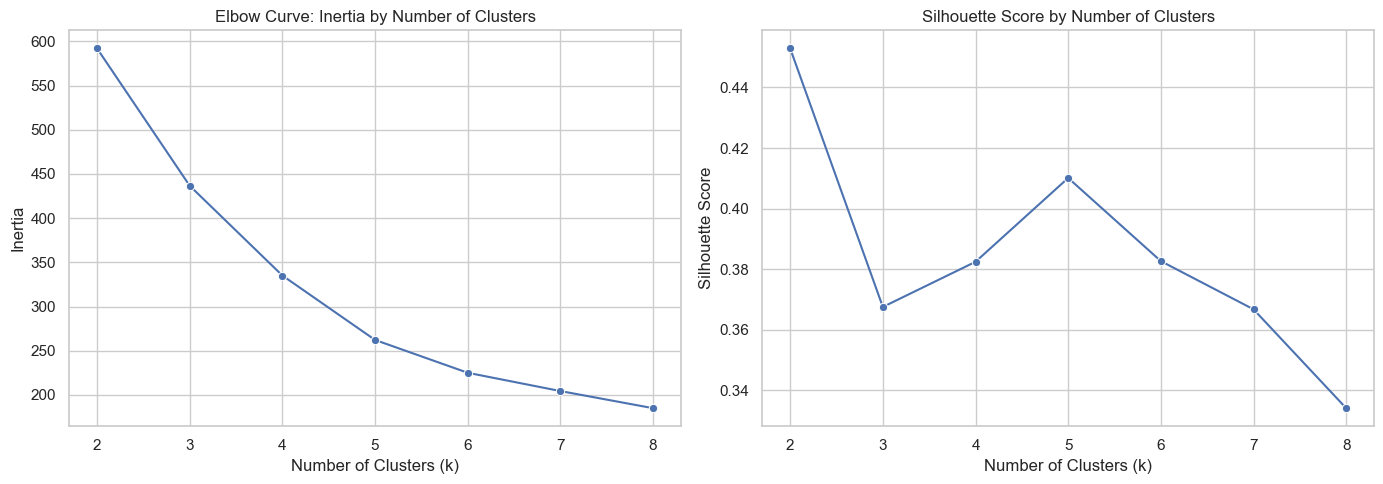

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=k_results, x='k', y='inertia', marker='o', ax=axes[0])
axes[0].set_title('Elbow Curve: Inertia by Number of Clusters')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(k_values)

sns.lineplot(data=k_results, x='k', y='silhouette_score', marker='o', ax=axes[1])
axes[1].set_title('Silhouette Score by Number of Clusters')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(k_values)

plt.tight_layout()
plt.show()


In [7]:
best_silhouette_row = k_results.loc[k_results['silhouette_score'].idxmax()]

summary = f"""### Cluster-selection findings

- Values from **k = {k_values[0]}** through **k = {k_values[-1]}** were evaluated.
- The highest silhouette score occurred at **k = {int(best_silhouette_row['k'])}** with a score of **{best_silhouette_row['silhouette_score']:.3f}**.
- The final selection also considers the elbow curve and whether the resulting profiles form useful, interpretable vehicle segments.
"""
display(Markdown(summary))


### Cluster-selection findings

- Values from **k = 2** through **k = 8** were evaluated.
- The highest silhouette score occurred at **k = 2** with a score of **0.453**.
- The final selection also considers the elbow curve and whether the resulting profiles form useful, interpretable vehicle segments.


## Final K-Means model

Three clusters are used for the final model because they provide a concise segmentation of the automobile market while retaining meaningful differences in vehicle size, performance, and fuel economy. Cluster labels are identifiers only; their interpretation comes from the feature profiles shown below.


In [8]:
final_k = 3

kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df_clustered = df_clean.copy()
df_clustered['cluster'] = kmeans_final.fit_predict(X_cluster_scaled)

cluster_counts = df_clustered['cluster'].value_counts().sort_index()
display(cluster_counts.to_frame('number_of_cars'))
display(df_clustered[['cluster'] + cluster_features + ['price']].head())


c:\Users\hp\miniconda3\envs\da\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,number_of_cars
cluster,
0,57
1,67
2,77


,cluster,engine_size,horsepower,curb_weight,wheel_base,city_mpg,highway_mpg,price
0,2,130,111.0,2548,88.6,21,27,13495.0
1,2,130,111.0,2548,88.6,21,27,16500.0
2,1,152,154.0,2823,94.5,19,26,16500.0
3,2,109,102.0,2337,99.8,24,30,13950.0
4,1,136,115.0,2824,99.4,18,22,17450.0


## Cluster profiles

The profile tables compare the typical feature values and prices of the resulting segments. Because price was not used during clustering, differences in average price provide an independent way to understand how the technical vehicle segments relate to the market.


In [9]:
cluster_profile = (
    df_clustered
    .groupby('cluster')[cluster_features + ['price']]
    .mean()
    .round(2)
)

cluster_size = (
    df_clustered['cluster']
    .value_counts()
    .sort_index()
    .rename('number_of_cars')
)

cluster_summary = cluster_profile.join(cluster_size)
display(cluster_summary)

cluster_medians = (
    df_clustered
    .groupby('cluster')[cluster_features + ['price']]
    .median()
    .round(2)
)
display(cluster_medians)


,engine_size,horsepower,curb_weight,wheel_base,city_mpg,highway_mpg,price,number_of_cars
cluster,,,,,,,,
0,94.49,67.07,2024.89,94.45,33.05,38.93,7105.40,57
1,168.93,142.42,3154.99,104.17,19.39,24.27,21457.63,67
2,114.26,96.15,2427.09,97.34,24.39,30.17,10544.99,77


,engine_size,horsepower,curb_weight,wheel_base,city_mpg,highway_mpg,price
cluster,,,,,,,
0,92.0,68.0,1989.0,94.5,31.0,38.0,6918.0
1,156.0,145.0,3071.0,104.3,19.0,24.0,18150.0
2,110.0,94.0,2395.0,97.0,24.0,30.0,9960.0


In [10]:
profile_for_labels = cluster_profile.copy()
low_price_cluster = profile_for_labels['price'].idxmin()
high_price_cluster = profile_for_labels['price'].idxmax()

def describe_cluster(cluster_id):
    row = profile_for_labels.loc[cluster_id]
    return (
        f'Cluster {cluster_id} contains {int(cluster_size.loc[cluster_id])} vehicles and has an average '
        f'engine size of {row["engine_size"]:.0f}, horsepower of {row["horsepower"]:.0f}, '
        f'curb weight of {row["curb_weight"]:.0f}, city fuel economy of {row["city_mpg"]:.1f} MPG, '
        f'and an average price of ${row["price"]:,.0f}.'
    )

segment_lines = '\n'.join(
    f'- {describe_cluster(cluster_id)}'
    for cluster_id in sorted(profile_for_labels.index)
)

summary = f"""### Segment findings

{segment_lines}

- Cluster **{low_price_cluster}** has the lowest average price, while cluster **{high_price_cluster}** has the highest average price.
- These groups should be interpreted as data-driven technical segments rather than fixed market labels.
"""
display(Markdown(summary))


### Segment findings

- Cluster 0 contains 57 vehicles and has an average engine size of 94, horsepower of 67, curb weight of 2025, city fuel economy of 33.0 MPG, and an average price of $7,105.
- Cluster 1 contains 67 vehicles and has an average engine size of 169, horsepower of 142, curb weight of 3155, city fuel economy of 19.4 MPG, and an average price of $21,458.
- Cluster 2 contains 77 vehicles and has an average engine size of 114, horsepower of 96, curb weight of 2427, city fuel economy of 24.4 MPG, and an average price of $10,545.

- Cluster **0** has the lowest average price, while cluster **1** has the highest average price.
- These groups should be interpreted as data-driven technical segments rather than fixed market labels.


## Segment visualizations

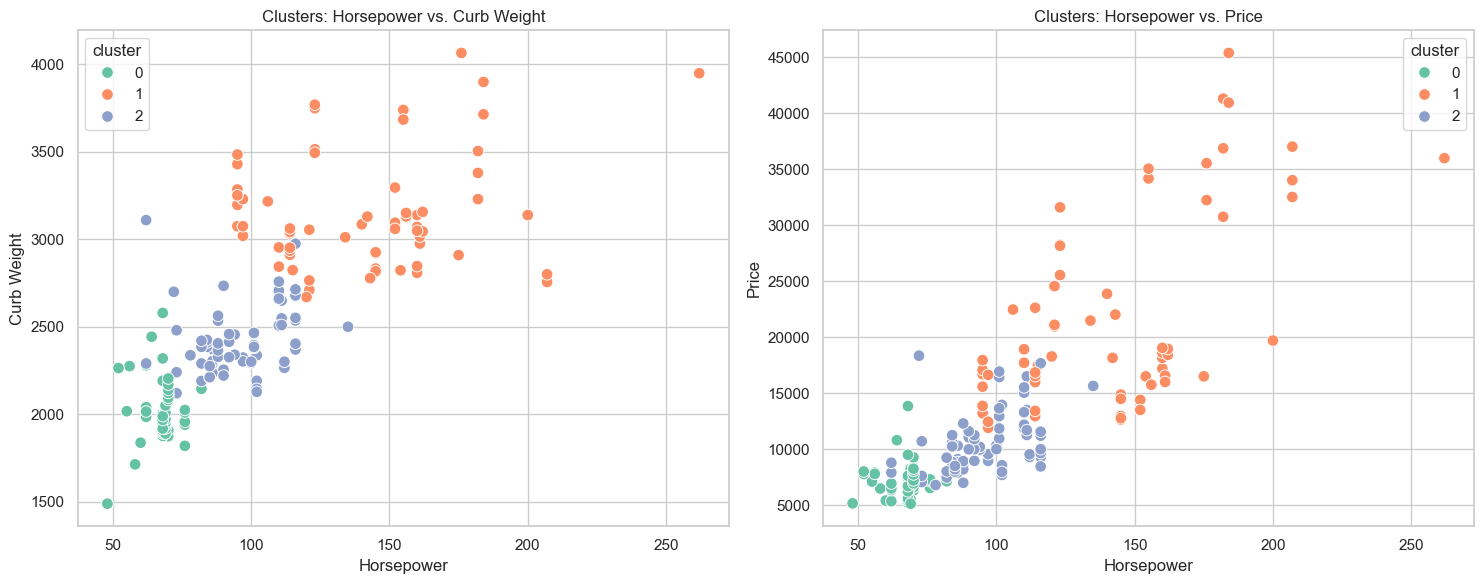

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=df_clustered, x='horsepower', y='curb_weight', hue='cluster', palette='Set2', s=70, ax=axes[0])
axes[0].set_title('Clusters: Horsepower vs. Curb Weight')
axes[0].set_xlabel('Horsepower')
axes[0].set_ylabel('Curb Weight')

sns.scatterplot(data=df_clustered, x='horsepower', y='price', hue='cluster', palette='Set2', s=70, ax=axes[1])
axes[1].set_title('Clusters: Horsepower vs. Price')
axes[1].set_xlabel('Horsepower')
axes[1].set_ylabel('Price')

plt.tight_layout()
plt.show()


c:\Users\hp\miniconda3\envs\da\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


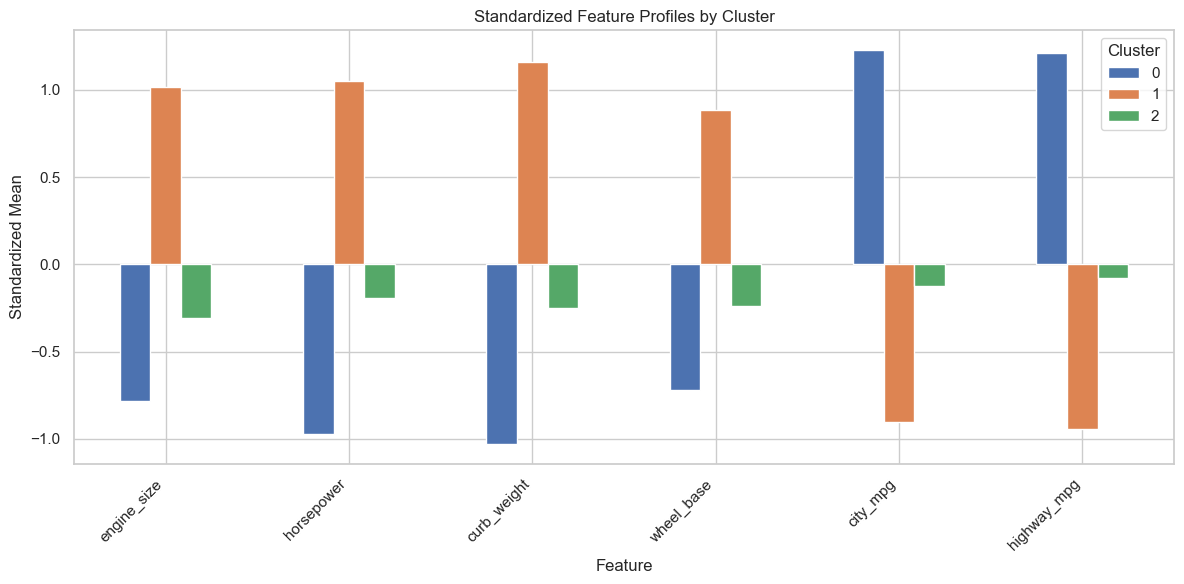

In [12]:
cluster_means_scaled = pd.DataFrame(
    cluster_scaler.transform(cluster_profile[cluster_features]),
    columns=cluster_features,
    index=cluster_profile.index
)

cluster_means_scaled.T.plot(kind='bar', figsize=(12, 6))
plt.title('Standardized Feature Profiles by Cluster')
plt.xlabel('Feature')
plt.ylabel('Standardized Mean')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


## Export clustered data

The exported file retains all columns from the cleaned dataset and adds the `cluster` assignment. It can be used in the regression notebook to test whether segmentation contributes useful predictive information.


In [13]:
output_dir = Path('../data/processed')
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / 'automobiles_with_clusters.csv'
df_clustered.to_csv(output_file, index=False)

print(f'Saved: {output_file.resolve()}')
print(f'Exported shape: {df_clustered.shape[0]} rows x {df_clustered.shape[1]} columns')


Saved: E:\GitHub\FinalTlabz\data\processed\automobiles_with_clusters.csv
Exported shape: 201 rows x 27 columns


## Clustering conclusion

In [14]:
final_silhouette = k_results.loc[k_results['k'] == final_k, 'silhouette_score'].iloc[0]

summary = f"""### Summary of findings

- K-Means was applied to **{len(cluster_features)}** vehicle characteristics after median imputation and standardization.
- The final model used **k = {final_k}** clusters and achieved a silhouette score of **{final_silhouette:.3f}**.
- The clusters differ in their average engine size, horsepower, vehicle weight, and fuel efficiency.
- Price was excluded from model fitting but varies across the resulting technical segments.
- The clustered dataset was saved successfully: **{output_file.exists()}**.
- The next notebook will compare regression models for predicting automobile price and can evaluate the cluster variable as an additional feature.
"""
display(Markdown(summary))


### Summary of findings

- K-Means was applied to **6** vehicle characteristics after median imputation and standardization.
- The final model used **k = 3** clusters and achieved a silhouette score of **0.368**.
- The clusters differ in their average engine size, horsepower, vehicle weight, and fuel efficiency.
- Price was excluded from model fitting but varies across the resulting technical segments.
- The clustered dataset was saved successfully: **True**.
- The next notebook will compare regression models for predicting automobile price and can evaluate the cluster variable as an additional feature.


### Interpretation

The K-Means analysis identifies distinct groups of automobiles based on size, performance, weight, and fuel efficiency. The segments show that vehicles with larger engines, more horsepower, and greater curb weight generally appear in a different group from lighter, more fuel-efficient vehicles.

Although price was not included when the clusters were created, the average price differs across the groups. This suggests that the technical characteristics used for segmentation are also related to market value and may provide useful context for the later regression analysis.

The cluster assignments are not direct measures of vehicle quality or price level. Instead, they summarize patterns among automobiles with similar specifications and provide an additional perspective for analyzing the dataset.
